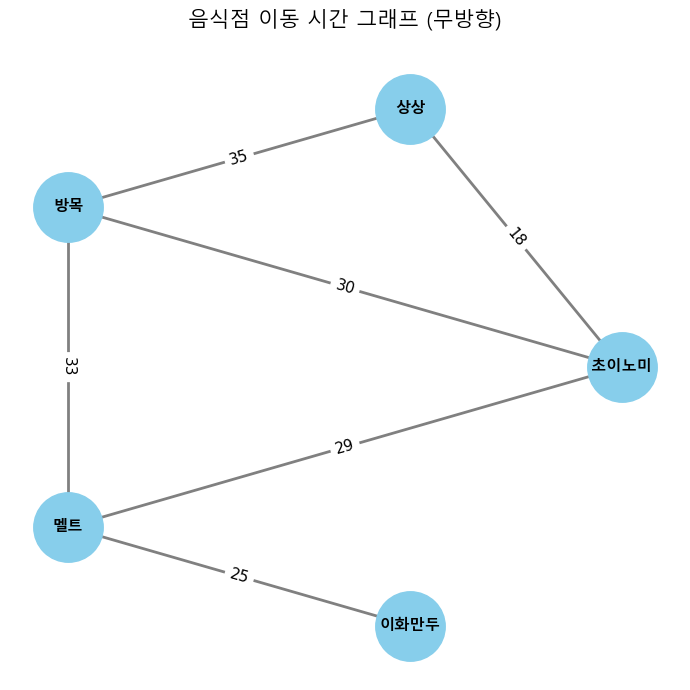

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows용 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# [새로운 CSV 기준 데이터] 코드 내 직접 삽입
graph_data = {
    ('초이노미', '상상'): 18,
    ('초이노미', '방목'): 30,
    ('초이노미', '멜트'): 29,
    ('상상', '방목'): 35,
    ('방목', '멜트'): 33,
    ('이화만두', '멜트'): 25
}

# 그래프 객체 생성 및 데이터 추가
G = nx.Graph()
for (u, v), w in graph_data.items():
    G.add_edge(u, v, weight=w)

# 고정된 원형 레이아웃 배치
pos = nx.circular_layout(G)

# 그래프 그리기 (단 한 개만 생성)
plt.figure(figsize=(7, 7))
plt.title("음식점 이동 시간 그래프 (무방향)", fontsize=15, pad=20)

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2500)
nx.draw_networkx_labels(G, pos, font_family=plt.rcParams['font.family'], font_size=11, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)

plt.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))

# 새로운 데이터 구조에 맞는 DFS 경로 추출
start_node = '초이노미'
dfs_edges = list(nx.dfs_edges(G, source=start_node))
visited_nodes = [start_node]
for u, v in dfs_edges:
    if v not in visited_nodes:
        visited_nodes.append(v)

def update(frame):
    ax.clear()
    ax.set_title(f"DFS 방문 과정 (Step {frame+1})", fontsize=16)
    
    current_nodes = visited_nodes[:frame+1]
    current_edges = dfs_edges[:frame]
    
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    node_colors = ['orange' if node in current_nodes else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_family='Malgun Gothic', font_size=12, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=current_edges, edge_color='red', width=3, ax=ax)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=len(visited_nodes), repeat=False, interval=1000)

# 파일 저장 후 캔버스 닫기 및 주피터 실행
ani.save('dfs.mp4', writer='ffmpeg')
plt.close()
HTML(ani.to_html5_video())

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))

# 새로운 데이터 구조에 맞는 BFS 경로 추출
start_node = '초이노미'
bfs_edges = list(nx.bfs_edges(G, source=start_node))
visited_nodes = [start_node]
for u, v in bfs_edges:
    if v not in visited_nodes:
        visited_nodes.append(v)

def update(frame):
    ax.clear()
    ax.set_title(f"BFS 방문 과정 (Step {frame+1})", fontsize=16)
    
    current_nodes = visited_nodes[:frame+1]
    current_edges = bfs_edges[:frame]
    
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    node_colors = ['tomato' if node in current_nodes else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_family='Malgun Gothic', font_size=12, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=current_edges, edge_color='blue', width=3, ax=ax)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=len(visited_nodes), repeat=False, interval=1000)

ani.save('bfs.mp4', writer='ffmpeg')
plt.close()
HTML(ani.to_html5_video())

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation
from IPython.display import HTML
import heapq

fig, ax = plt.subplots(figsize=(8, 6))

start_node = '초이노미'
mst_edges = []
mst_nodes = {start_node}
edges_queue = []

for neighbor in G.neighbors(start_node):
    heapq.heappush(edges_queue, (G[start_node][neighbor]['weight'], start_node, neighbor))

prim_steps = [(list(mst_nodes), list(mst_edges))]

while edges_queue:
    weight, u, v = heapq.heappop(edges_queue)
    if v not in mst_nodes:
        mst_nodes.add(v)
        mst_edges.append((u, v))
        prim_steps.append((list(mst_nodes), list(mst_edges)))
        for next_neighbor in G.neighbors(v):
            if next_neighbor not in mst_nodes:
                heapq.heappush(edges_queue, (G[v][next_neighbor]['weight'], v, next_neighbor))

def update(frame):
    ax.clear()
    ax.set_title(f"Prim 알고리즘 MST 생성 (Step {frame})", fontsize=16)
    
    current_nodes, current_edges = prim_steps[frame]
    
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    node_colors = ['green' if node in current_nodes else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_family='Malgun Gothic', font_size=12, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=current_edges, edge_color='green', width=4, ax=ax)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=len(prim_steps), repeat=False, interval=1200)

ani.save('prim.mp4', writer='ffmpeg')
plt.close()
HTML(ani.to_html5_video())

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))

parent = {node: node for node in G.nodes()}

def find(node):
    if parent[node] == node:
        return node
    parent[node] = find(parent[node])
    return parent[node]

def union(node1, node2):
    root1 = find(node1)
    root2 = find(node2)
    if root1 != root2:
        parent[root2] = root1
        return True
    return False

all_edges = sorted([(G[u][v]['weight'], u, v) for u, v in G.edges()])
kruskal_edges = []
kruskal_steps = [[]]

for weight, u, v in all_edges:
    if union(u, v):
        kruskal_edges.append((u, v))
        kruskal_steps.append(list(kruskal_edges))

def update(frame):
    ax.clear()
    ax.set_title(f"Kruskal 알고리즘 MST 생성 (Step {frame})", fontsize=16)
    
    current_edges = kruskal_steps[frame]
    current_nodes = set([n for edge in current_edges for n in edge])
    
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    node_colors = ['purple' if node in current_nodes else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_family='Malgun Gothic', font_size=12, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=current_edges, edge_color='purple', width=4, ax=ax)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=len(kruskal_steps), repeat=False, interval=1200)

ani.save('kruskal.mp4', writer='ffmpeg')
plt.close()
HTML(ani.to_html5_video())